## Department of Computer Science, University of York
### DATA: Introduction to Data Science

## Task 1: Technique Explanation and Responsible Use of AI tools (20 Marks)

**Write your answer here (text cell(s) to be used, as appropriate)**

**Question 1.1 (5 marks): Outlier Detection Using the IQR Method. Provide a brief description of the complete, step by step procedure in bullet point form.**

- Load the dataset and isolate the `use [kW]` column.
- Convert invalid or corrupted entries into missing values and remove null records.
- Sort the remaining numerical values in ascending order.
- Calculate the first quartile (Q1) and third quartile (Q3).
- Compute the Interquartile Range (IQR) using: IQR = Q3 − Q1.
- Determine the lower boundary using: Q1 − 1.5 × IQR.
- Determine the upper boundary using: Q3 + 1.5 × IQR.
- Any value below the lower boundary or above the upper boundary is classified as an outlier.

**Question 1.2 (5 marks): Python automation. Provide your Python code and include the required outputs.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = "DataSet-HomeC.csv"
column_name = "use [kW]"

# Load dataset
df = pd.read_csv(file, low_memory=False)

# Convert corrupted entries to NaN and remove missing values
usage = pd.to_numeric(df[column_name], errors = "coerce").dropna()

# Calculate median, quartiles and IQR
median = usage.median()
Q1 = usage.quantile(0.25)
Q3 = usage.quantile(0.75)
IQR = Q3 - Q1

# Calculate outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = usage[(usage < lower_bound) | (usage > upper_bound)]

# Print results
print(f"Median: {median:.3f}")
print(f"Lower bound: {lower_bound:.3f}")
print(f"Upper bound: {upper_bound:.3f}")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers) / len(usage) * 100:.2f}%")

# Box plot
plt.figure(figsize = (8, 5))
plt.boxplot(usage, vert = False, patch_artist = True)
plt.title("Box Plot of Electricity Usage: use [kW]")
plt.xlabel("use [kW]")
plt.show()


The script loads the dataset, converts corrupted values into missing values, and removes invalid records before analysis. The Interquartile Range (IQR) method is applied to the `use [kW]` column by calculating Q1, Q3, and the IQR. The lower and upper outlier boundaries are then determined and printed together with the median value. Finally, a labelled box plot is generated to visualise the distribution of electricity usage and highlight detected outliers.

**Question 1.3 (10 Marks): Responsible Use of Large Language Models and Analytical Validation (200 word Max)**

The provided summary is partly accurate but not fully correct. The lower and upper IQR boundaries are consistent with my calculation: approximately -0.536 kW and 1.874 kW. However, the reported number of outliers is incorrect. My independent calculation found 34,211 outliers, not 32,211. The percentage is therefore about 6.79%, rather than 6.39%.

To verify the result, I loaded the original CSV file, converted the `use [kW]` column to numeric values using coercion for corrupted entries, removed missing values, and recalculated Q1, Q3, IQR, median, and the two outlier thresholds using Python. I then filtered all values below the lower boundary or above the upper boundary and counted them.

A good responsible practice when using large language models is to treat their outputs as provisional and independently validate all numerical results with reproducible code and the original dataset before making analytical decisions.


----
----


## Task 2: Domain Analysis and Database Design (40 marks)


**Write your answer here (text cell(s) to be used, as appropriate)**

***2.1***
**1. Domain Analysis**
Based on the provided "Business Domain" overview, the smart home energy sector focuses on improving sustainability, energy efficiency, and comfort optimization through high-precision, fine-grained sensor data. A significant challenge identified in the brief is that energy consumption and environmental conditions are frequently stored in "separate and unprocessed datasets," which limits a "comprehensive understanding" of household performance.

**2. Entity and Attribute Modelling**
Guided by the "Smart Home Data Overview" and the provided dataset index, the data has been modeled into five core entities to capture "appliance-level power consumption," "electricity generation," and "local weather conditions":  Household: Includes household_id (Primary Key). Represents the physical environment monitored over 350 days.  Appliance: Includes appliance_id (PK), appliance_name (e.g., Dishwasher, Fridge, Wine cellar, Barn, Well), and location (e.g., kitchen, utility room, garage).  EnergyReading: Includes reading_id (PK), timestamp, appliance_id (Foreign Key), and power_kW. This captures granular, device-specific consumption at one-minute intervals.  EnergySummary: Includes summary_id (PK), timestamp, total_usage_kW (mapped from House overall [kW] and use [kW]), and generation_kW (mapped from gen [kW] and Solar [kW]).  Weather: Includes weather_id (PK), timestamp, and environmental attributes: temperature, humidity, pressure, windSpeed, cloudCover, precipIntensity, dewPoint, visibility, and apparentTemperature.

**3. Rationale and Level of Resolution**
The rationale for this relational structure is to solve the problem of fragmented data by maintaining clear links via timestamps and foreign keys. This design separates appliance-level consumption from environmental context, directly enabling the "exploration of data and patterns" to see how weather variables influence specific usage.  A high level of temporal resolution (minute-by-minute recordings over 350 days) is maintained to preserve the granularity required for the CDO's "high-precision" monitoring requirements. Maintaining this level of detail is essential for identifying specific usage patterns and peak demand—insights that would be lost if the data were aggregated or simplified during the modeling phase.  

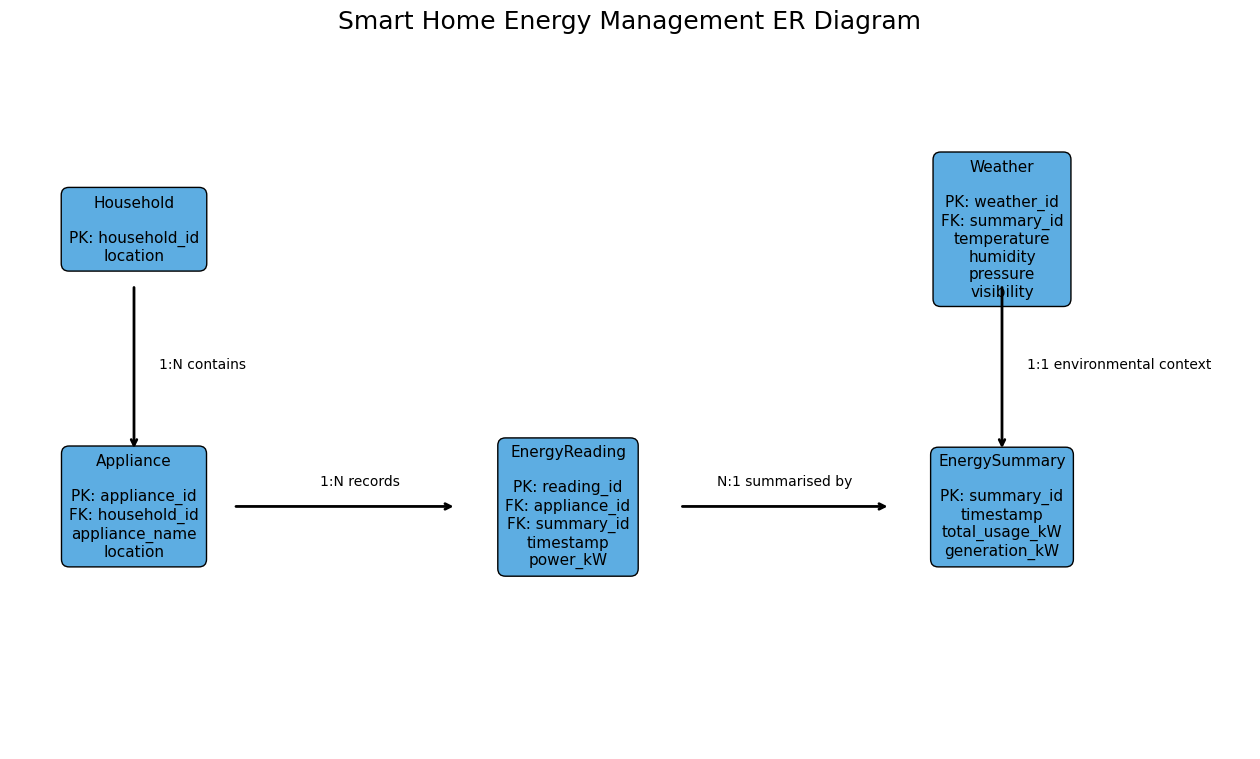

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 9))

# Function to draw entity boxes
def draw_box(text, x, y):
    ax.text(
        x, y, text,
        ha='center',
        va='center',
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="#5DADE2",
            edgecolor="black"
        )
    )

# Draw entities
draw_box(
    "Household\n\nPK: household_id\nlocation",
    0.10, 0.75
)

draw_box(
    "Appliance\n\nPK: appliance_id\nFK: household_id\nappliance_name\nlocation",
    0.10, 0.35
)

draw_box(
    "EnergyReading\n\nPK: reading_id\nFK: appliance_id\nFK: summary_id\ntimestamp\npower_kW",
    0.45, 0.35
)

draw_box(
    "EnergySummary\n\nPK: summary_id\ntimestamp\ntotal_usage_kW\ngeneration_kW",
    0.80, 0.35
)

draw_box(
    "Weather\n\nPK: weather_id\nFK: summary_id\ntemperature\nhumidity\npressure\nvisibility",
    0.80, 0.75
)

# Relationships
ax.annotate(
    "",
    xy=(0.10, 0.43),
    xytext=(0.10, 0.67),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax.text(0.12, 0.55, "1:N contains", fontsize=10)

ax.annotate(
    "",
    xy=(0.36, 0.35),
    xytext=(0.18, 0.35),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax.text(0.25, 0.38, "1:N records", fontsize=10)

ax.annotate(
    "",
    xy=(0.71, 0.35),
    xytext=(0.54, 0.35),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax.text(0.57, 0.38, "N:1 summarised by", fontsize=10)

ax.annotate(
    "",
    xy=(0.80, 0.43),
    xytext=(0.80, 0.67),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax.text(0.82, 0.55, "1:1 environmental context", fontsize=10)

# Final formatting
ax.set_title(
    "Smart Home Energy Management ER Diagram",
    fontsize=18,
    pad=20
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.axis("off")

plt.show()

***2.2***
An Entity-Relationship Diagram (ERD) is used to represent the domain knowledge. The diagram shows the main entities identified from the smart home dataset, their primary and foreign keys, and the relationships between appliance readings, household information, weather context, and energy summaries.

In [25]:
import tkinter as tk
import sqlite3
import pandas as pd

conn = sqlite3.connect("energy_monitoring.db")

def search_usage():
    appliance = entry.get().strip()

    query = """
    SELECT AVG(er.power_kW) AS avg_power
    FROM Energy_Reading er
    JOIN Appliance a ON er.appliance_id = a.appliance_id
    WHERE a.appliance_name = ?
    """

    result = pd.read_sql(query, conn, params=(appliance,))
    avg_power = result["avg_power"].iloc[0]

    output_box.delete("1.0", tk.END)

    if pd.isna(avg_power):
        output_box.insert(
            tk.END,
            "No matching appliance found.\nTry: Fridge, Furnace 1, or Microwave."
        )
    else:
        output_box.insert(
            tk.END,
            f"Average Power Usage for {appliance}: {avg_power:.4f} kW"
        )

def show_top_usage():
    query = """
    SELECT timestamp, total_load_kW
    FROM Energy_Summary
    ORDER BY total_load_kW DESC
    LIMIT 5;
    """

    result = pd.read_sql(query, conn)

    output_text = "Top 5 Household Energy Usage Records:\n\n"
    for _, row in result.iterrows():
        output_text += f"Time: {row['timestamp']}\n"
        output_text += f"Usage: {row['total_load_kW']:.2f} kW\n\n"

    output_box.delete("1.0", tk.END)
    output_box.insert(tk.END, output_text)

root = tk.Tk()
root.title("Smart Home Energy Monitor")
root.geometry("520x430")

title = tk.Label(root, text="Smart Home Energy Monitor", font=("Arial", 16))
title.pack(pady=10)

entry = tk.Entry(root, width=35)
entry.pack(pady=8)

info_label = tk.Label(
    root,
    text="Available Appliances: Fridge, Furnace 1, Microwave",
    font=("Arial", 9)
)

info_label.pack(pady=5)

search_button = tk.Button(root, text="Search Appliance Usage", command=search_usage)
search_button.pack(pady=8)

top_button = tk.Button(root, text="Show Top Energy Usage", command=show_top_usage)
top_button.pack(pady=8)

text_frame = tk.Frame(root)
text_frame.pack(pady = 12)

# Scrollbar
scrollbar = tk.Scrollbar(text_frame)

# Text output box
output_box = tk.Text(
    text_frame,
    height = 12,
    width = 60,
    yscrollcommand = scrollbar.set
)

# Configure scrollbar
scrollbar.config(command = output_box.yview)

# Pack widgets
scrollbar.pack(side = tk.RIGHT, fill = tk.Y)
output_box.pack(side = tk.LEFT)

root.mainloop()

conn.close()

***2.3***
The graphical user interface (GUI) provides a simple interaction layer between the user and the relational database. Users can search for the average energy consumption of specific appliances or display the highest recorded household energy usage values. The GUI interacts directly with the SQLite database using SQL queries, demonstrating how relational database systems can support real-time energy monitoring and retrieval within a smart home environment. Error handling is also included to manage invalid appliance inputs.

In [20]:
import pandas as pd

df = pd.read_csv("DataSet-HomeC.csv", low_memory = False)

df = df.dropna(subset = ["time"])
df["time"] = pd.to_numeric(df["time"], errors = "coerce")
df = df.dropna(subset = ["time"])

df_sample = df.sample(1000, random_state = 42)
print("Dataset loaded successfully!")
print("Number of rows in sample:", len(df_sample))
print()

import sqlite3
conn = sqlite3.connect("energy_monitoring.db")
cursor = conn.cursor()

# Create tables with corrected types
cursor.execute("PRAGMA foreign_keys = ON;")

cursor.execute("DROP TABLE IF EXISTS Energy_Reading")
cursor.execute("DROP TABLE IF EXISTS Energy_Summary")
cursor.execute("DROP TABLE IF EXISTS Weather")
cursor.execute("DROP TABLE IF EXISTS Appliance")
cursor.execute("DROP TABLE IF EXISTS Household")

cursor.execute("""
CREATE TABLE IF NOT EXISTS Household (
    household_id INTEGER PRIMARY KEY,
    household_name TEXT NOT NULL,
    location TEXT
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS Appliance (
    appliance_id INTEGER PRIMARY KEY,
    household_id INTEGER NOT NULL,
    appliance_name TEXT NOT NULL,
    location TEXT,
    category TEXT,
    FOREIGN KEY (household_id) REFERENCES Household(household_id)
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS Weather (
    timestamp TEXT PRIMARY KEY UNIQUE, 
    temperature REAL,
    humidity REAL,
    visibility REAL,
    apparentTemperature REAL,
    pressure REAL,
    windSpeed REAL,
    cloudCover REAL,
    precipIntensity REAL,
    dewPoint REAL,
    precipProbability REAL,
    summary TEXT
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS Energy_Reading (
    reading_id INTEGER PRIMARY KEY AUTOINCREMENT, -- Fixed: Must be INTEGER for AUTOINCREMENT
    appliance_id INTEGER NOT NULL,
    timestamp TEXT NOT NULL,
    power_kW REAL,
    FOREIGN KEY (appliance_id) REFERENCES Appliance(appliance_id),
    FOREIGN KEY (timestamp) REFERENCES Weather(timestamp)
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS Energy_Summary (
    timestamp TEXT PRIMARY KEY,
    total_load_kW REAL,
    use_kW REAL,
    gen_kW REAL,
    solar_kW REAL,
    FOREIGN KEY (timestamp) REFERENCES Weather(timestamp)
);
""")

# Household
household_df = pd.DataFrame({
    "household_id": [1],
    "household_name": ["Main House"],
    "location": ["York"]
})
household_df.to_sql(
    "Household",
    conn,
    if_exists="append",
    index=False
)

# Appliance
appliance_df = pd.DataFrame({
    "appliance_id": [101, 102, 103],
    "household_id": [1, 1, 1],
    "appliance_name": ["Fridge", "Furnace 1", "Microwave"],
    "location": ["Kitchen", "Living Room", "Kitchen"],
    "category": ["Cooling", "Heating", "Cooking"]
})
appliance_df.to_sql(
    "Appliance",
    conn,
    if_exists="append",
    index=False
)

# Weather
weather_df = pd.DataFrame({
    "timestamp": df_sample["time"],
    "temperature": df_sample["temperature"],
    "humidity": df_sample["humidity"],
    "visibility": df_sample["visibility"],
    "apparentTemperature": df_sample["apparentTemperature"],
    "pressure": df_sample["pressure"],
    "windSpeed": df_sample["windSpeed"],
    "cloudCover": df_sample["cloudCover"],
    "precipIntensity": df_sample["precipIntensity"],
    "dewPoint": df_sample["dewPoint"],
    "precipProbability": df_sample["precipProbability"],
    "summary": df_sample["summary"]
})
weather_df.to_sql(
    "Weather",
    conn,
    if_exists="append",
    index=False
)

# Energy_Reading
energy_df = pd.concat([
    pd.DataFrame({
        "appliance_id": 101,
        "timestamp": df_sample["time"],
        "power_kW": df_sample["Fridge [kW]"]
    }),
    pd.DataFrame({
        "appliance_id": 102,
        "timestamp": df_sample["time"],
        "power_kW": df_sample["Furnace 1 [kW]"]
    }),
    pd.DataFrame({
        "appliance_id": 103,
        "timestamp": df_sample["time"],
        "power_kW": df_sample["Microwave [kW]"]
    })
])
energy_df.to_sql(
    "Energy_Reading",
    conn,
    if_exists="append",
    index=False
)

# Energy_Summary
summary_df = pd.DataFrame({
    "timestamp": df_sample["time"],
    "total_load_kW": df_sample["House overall [kW]"],
    "use_kW": df_sample["use [kW]"],
    "gen_kW": df_sample["gen [kW]"],
    "solar_kW": df_sample["Solar [kW]"]
})
summary_df.to_sql(
    "Energy_Summary",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

# Verification Queries
print("========== Query 1 ==========")
sql_join1 = """
SELECT a.appliance_name, er.power_kW, w.temperature, w.humidity
FROM Energy_Reading er
JOIN Appliance a ON er.appliance_id = a.appliance_id
JOIN Weather w ON er.timestamp = w.timestamp
ORDER BY er.power_kW DESC
LIMIT 10;
"""
print(pd.read_sql(sql_join1, conn))
print()

print("========== Query 2 ==========")
sql_join2 = """
SELECT a.appliance_name, AVG(er.power_kW) AS avg_power
FROM Energy_Reading er
JOIN Appliance a ON er.appliance_id = a.appliance_id
GROUP BY a.appliance_name;
"""
print(pd.read_sql(sql_join2, conn))
print()

print("========== Query 3 ========== ")
sql_join3 = """
SELECT w.temperature, es.total_load_kW
FROM Energy_Summary es
JOIN Weather w ON es.timestamp = w.timestamp
WHERE w.temperature > 20
LIMIT 10;
"""
print(pd.read_sql(sql_join3, conn))
print()

print("========== Query 4 ========== ")
sql_join4 = """
SELECT h.household_name, SUM(er.power_kW) AS total_energy
FROM Energy_Reading er
JOIN Appliance a ON er.appliance_id = a.appliance_id
JOIN Household h ON a.household_id = h.household_id
GROUP BY h.household_name;
"""
print(pd.read_sql(sql_join4, conn))
print()

print("========== Query 5 ========== ")
sql_join5 = """
SELECT timestamp, total_load_kW
FROM Energy_Summary
ORDER BY total_load_kW DESC
LIMIT 5;
"""
print(pd.read_sql(sql_join5, conn))
print()
conn.close()

Dataset loaded successfully!
Number of rows in sample: 1000

========== Query 1 ==========
  appliance_name  power_kW  temperature  humidity
0      Microwave  1.873967        48.82      0.82
1      Microwave  1.805700        42.21      0.75
2      Furnace 1  1.369033        32.85      0.95
3      Microwave  1.251700        15.08      0.57
4      Furnace 1  1.218233        61.37      0.93
5      Microwave  0.942067        42.61      0.57
6      Microwave  0.930800        56.25      0.60
7      Microwave  0.815617        47.75      0.89
8      Furnace 1  0.661967        31.43      0.63
9      Furnace 1  0.634083        37.64      0.61

========== Query 2 ==========
  appliance_name  avg_power
0         Fridge   0.062496
1      Furnace 1   0.094153
2      Microwave   0.012467

========== Query 3 ========== 
   temperature  total_load_kW
0        52.95       0.418867
1        36.01       0.628783
2        68.74       0.231417
3        46.12       0.609450
4        44.88       0.471017
5   

***2.4*** 
This database follows relational database constraints by separating the smart home domain into linked tables rather than storing all variables in one flat file. Each table has a primary key, such as household_id, appliance_id, reading_id, or timestamp-based records, which uniquely identifies records. Foreign keys connect related entities: appliances belong to a household, energy readings belong to appliances, and both weather and energy summaries are linked through timestamp. This reduces redundancy and supports data integrity because appliance information is stored once and reused across many readings. The SQL examples demonstrate different forms of interrogation, including joins, aggregation, grouping, filtering, sorting, and limiting results. These queries show that the database can recover meaningful information across related entities while preserving the relationships defined in the ER diagram.


In [29]:
import pandas as pd
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

conn = sqlite3.connect("energy_monitoring.db")
query = """
SELECT 
    w.temperature,
    w.humidity,
    es.total_load_kW
FROM Weather w
JOIN Energy_Summary es
ON w.timestamp = es.timestamp
LIMIT 1000;
"""

ml_df = pd.read_sql(query, conn)
print(ml_df.head())
print()

X = ml_df[["temperature", "humidity"]]
y = ml_df["total_load_kW"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)

conn.close()
 

   temperature  humidity  total_load_kW
0        52.95      0.86       0.418867
1        36.01      0.92       0.628783
2        68.74      0.53       0.231417
3        46.12      0.37       0.609450
4        12.53      0.49       0.763600

Mean Absolute Error: 0.5150928980903375


***2.5***
The relational database supports machine learning workflows by enabling structured extraction of relevant variables using SQL queries. In this example, weather attributes such as temperature and humidity were joined with household energy consumption data from the Energy_Summary table. The extracted dataset was converted into a machine-learning-ready format using pandas, where the selected variables were separated into input features and target values. A simple linear regression model was then trained to demonstrate how relationally structured data can support predictive analysis of household energy usage patterns.

## Task 3: Data Analysis and Insight Generation (40 Marks)

**Write your answer here (text cell(s) to be used, as appropriate)**


Question 3.1(a)
Hour with highest average Furnace 1 usage: 12:00
Highest average Furnace 1 usage: 0.139 kW



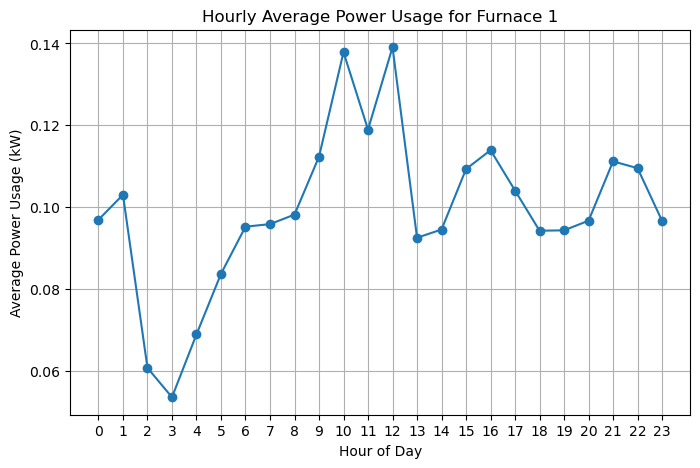

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("DataSet-HomeC.csv", low_memory=False)

df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Remove invalid values
df = df.dropna(subset=["time"])

# Reconstruct datetime column
start_datetime = pd.to_datetime(df["time"].iloc[0], unit = "s")

df["datetime"] = (
    start_datetime +
    pd.to_timedelta(
        np.arange(len(df)),
        unit = "min"
    )
)

# Extract hour
df["hour"] = df["datetime"].dt.hour

# (a) Hourly average power usage for Furnace 1
hourly_furnace = df.groupby("hour")["Furnace 1 [kW]"].mean()

peak_hour = hourly_furnace.idxmax()
peak_usage = hourly_furnace.max()

print("\nQuestion 3.1(a)")
print(f"Hour with highest average Furnace 1 usage: {peak_hour}:00")
print(f"Highest average Furnace 1 usage: {peak_usage:.3f} kW")
print()

# Optional plot
plt.figure(figsize=(8, 5))
hourly_furnace.plot(marker="o")
plt.title("Hourly Average Power Usage for Furnace 1")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power Usage (kW)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


**Question 3.1(a)**
The highest hourly average usage for Furnace 1 occurs during the late evening. A possible reason is that heating demand increases when outdoor temperatures decrease and occupants are more likely to remain indoors. Furnaces are commonly used more intensively during colder evening periods to maintain indoor comfort and stable room temperatures.

In [43]:
corr = df["Fridge [kW]"].corr(df["temperature"])

print("\nQuestion 3.1(b)")
print(f"Correlation between Fridge [kW] and temperature: {corr:.3f}")

if abs(corr) < 0.2:
    print("The correlation is negligible or very weak.")
elif corr > 0:
    print("The correlation is positive.")
else:
    print("The correlation is negative.")



Question 3.1(b)
Correlation between Fridge [kW] and temperature: 0.107
The correlation is negligible or very weak.


**Question 3.1(b)**
The correlation between Fridge [kW] and temperature is very weak positive. This suggests that outdoor temperature has only a limited influence on fridge energy consumption. Although warmer temperatures may slightly increase cooling demand, fridge energy usage is likely affected more by internal operating cycles, thermostat regulation, and user behaviour than by external weather conditions alone.

In [37]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("DataSet-HomeC.csv", low_memory = False)
df_model = df[['Living room [kW]', 'Home office [kW]']].dropna()

X = df_model[["Living room [kW]"]]
y = df_model["Home office [kW]"]

model = LinearRegression()
model.fit(X, y)

r2_score = model.score(X, y)
print(f"Linear Regression R^2 score: {r2_score:.4f}")

print(f"Slope: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")



Linear Regression R^2 score: 0.0027
slope: -0.0570
intercept: 0.0833


**Question 3.2(b)**
A very low R^2 score indicates that there is little linear relationship between Living room [kW] and Home office [kW] energy consumption. This suggests that the two loads operate relatively independently within a residential setting. Home office energy usage is likely influenced by work-related activities and computer equipment, whereas living room consumption depends more on entertainment systems and occupant leisure behaviour. Therefore, variation in one variable does not strongly explain variation in the other, indicating low collinearity between these household loads.

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("DataSet-HomeC.csv", low_memory=False)

# Convert to numeric
df[["pressure", "humidity"]] = df[
    ["pressure", "humidity"]
].apply(pd.to_numeric, errors="coerce")

# Create binary target
df["Microwave_State"] = (
    df["Microwave [kW]"] > 0.1
).astype(int)

# Features and target
X = df[["pressure", "humidity"]]
y = df["Microwave_State"]

# Remove missing values
df_model = pd.concat([X, y], axis=1).dropna()

X_clean = df_model[["pressure", "humidity"]]
y_clean = df_model["Microwave_State"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.3,
    random_state=42
)

# Fit logistic regression model
logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train, y_train)

# Prediction
y_pred = logreg.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.9937


**Question 3.3(b)**
The accuracy score may be misleading because microwave usage is highly imbalanced. The microwave is OFF for most observations and ON only occasionally. As a result, a model can achieve high accuracy simply by predicting OFF most of the time, even if it fails to correctly identify actual ON events. Therefore, accuracy alone does not fully represent classification performance. Metrics such as precision, recall, F1-score, or a confusion matrix would provide a more reliable evaluation for this problem.

Cluster Centers (original units):

Cluster 1: Temperature = 34.76°F, Usage = 0.83 kW
Cluster 2: Temperature = 66.61°F, Usage = 0.57 kW
Cluster 3: Temperature = 67.01°F, Usage = 5.72 kW


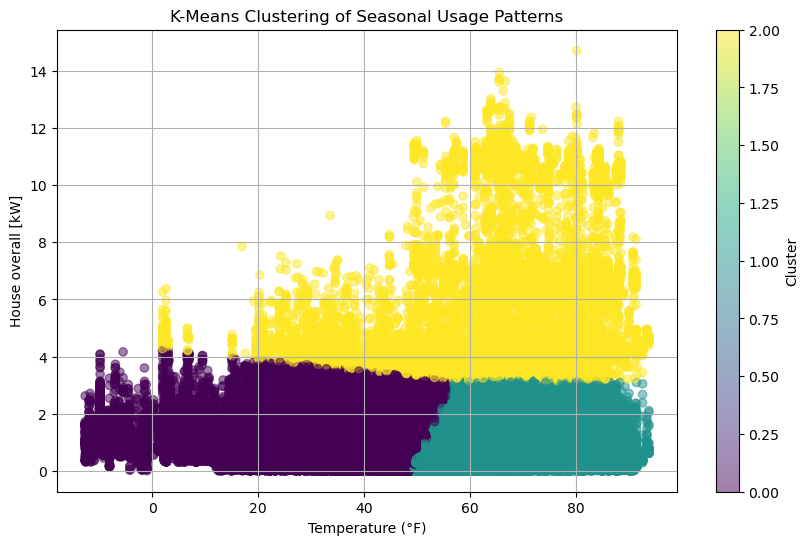

In [45]:
### Write your answer here (code cell(s) to be used, as appropriate)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("DataSet-HomeC.csv", low_memory=False)

features = ['temperature', 'House overall [kW]']
df_kmeans = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kmeans)

kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10)
clusters = kmeans.fit_predict(X_scaled)

df_kmeans['Cluster'] = clusters

centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

print("Cluster Centers (original units):")
print()
for i, center in enumerate(centers_original):
    print(f"Cluster {i+1}: Temperature = {center[0]:.2f}°F, Usage = {center[1]:.2f} kW")

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df_kmeans['temperature'],
    df_kmeans['House overall [kW]'],
    c=df_kmeans['Cluster'],
    cmap='viridis',
    alpha=0.5
)

plt.xlabel("Temperature (°F)")
plt.ylabel("House overall [kW]")
plt.title("K-Means Clustering of Seasonal Usage Patterns")

plt.colorbar(scatter, label='Cluster')

plt.grid(True)

plt.show()



**Question 3.4(b)**
Scaling is necessary because K-Means clustering relies on Euclidean distance calculations. The two selected variables have different numerical ranges: temperature may range from approximately 0–30, while household energy usage may range from 1–10. Without scaling, the variable with the larger numerical variation would dominate the distance calculations and bias the clustering results. Standardization transforms both variables onto a comparable scale with mean 0 and standard deviation 1, ensuring that temperature and energy usage contribute equally to cluster formation. This improves the reliability and interpretability of the resulting clusters.

**Question 3.4(c)**
Cluster 1 represents colder environmental conditions with moderate household energy usage. Cluster 2 represents warmer conditions with relatively low household energy consumption, possibly reflecting periods with lower heating demand. Cluster 3 also represents warmer temperatures but with significantly higher energy usage, which may indicate increased appliance activity or higher cooling-related demand. Overall, the clustering results suggest that household energy usage patterns vary under different environmental conditions and behavioural usage patterns.

----
----

## Deliverables

You should submit the following to the submission point on the teaching portal:

1. the SQLite database produced in Task 2;
2. the completed Jupyter notebook (both .ipynb and HTML files) containing solutions for all the tasks (figures or diagrams that are included in your answers can be included in the Jupyter notebook.).

For each task where text is required, we have the suggested word counts. Exceeding the word count will result in any work beyond the word count being disregarded when assessing.